In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import sys
sys.path.append('..')

from src.evaluate import evaluate, print_results
from src.dataset import get_dataloaders
from src.models import get_model
from src.gradcam import GradCAM

from PIL import Image
from torchvision import transforms

plt.rcParams['figure.dpi'] = 300

In [2]:
MODELS_DIR = os.path.join('..', 'outputs', 'models')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
FIGURES_DIR = os.path.join('..', 'outputs', 'figures')

train_loader, val_loader, test_loader = get_dataloaders(PROCESSED_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_resnet = get_model('resnet50').to(device)

checkpoint = torch.load(os.path.join(MODELS_DIR, 'resnet_50.pth'), map_location=device)
model_resnet.load_state_dict(checkpoint['model_state_dict'])
model_resnet.eval()
print(f"Loaded ResNet-50 from epoch {checkpoint['epoch']} with val loss {checkpoint['val_loss']:.4f}")

Trainable: 22,065,153 / 23,510,081
Loaded ResNet-50 from epoch 3 with val loss 0.0313


In [3]:
resnet_evaluation_results = evaluate(model = model_resnet, test_loader=test_loader, device=device)
print_results(resnet_evaluation_results, 'ResNet-50')


  ResNet-50 Results
  Accuracy:  0.9704
  Precision: 0.9858
  Recall:    0.9735
  F1 Score:  0.9796
  AUC-ROC:   0.9965
  Confusion Matrix:
[[229   9]
 [ 17 624]]



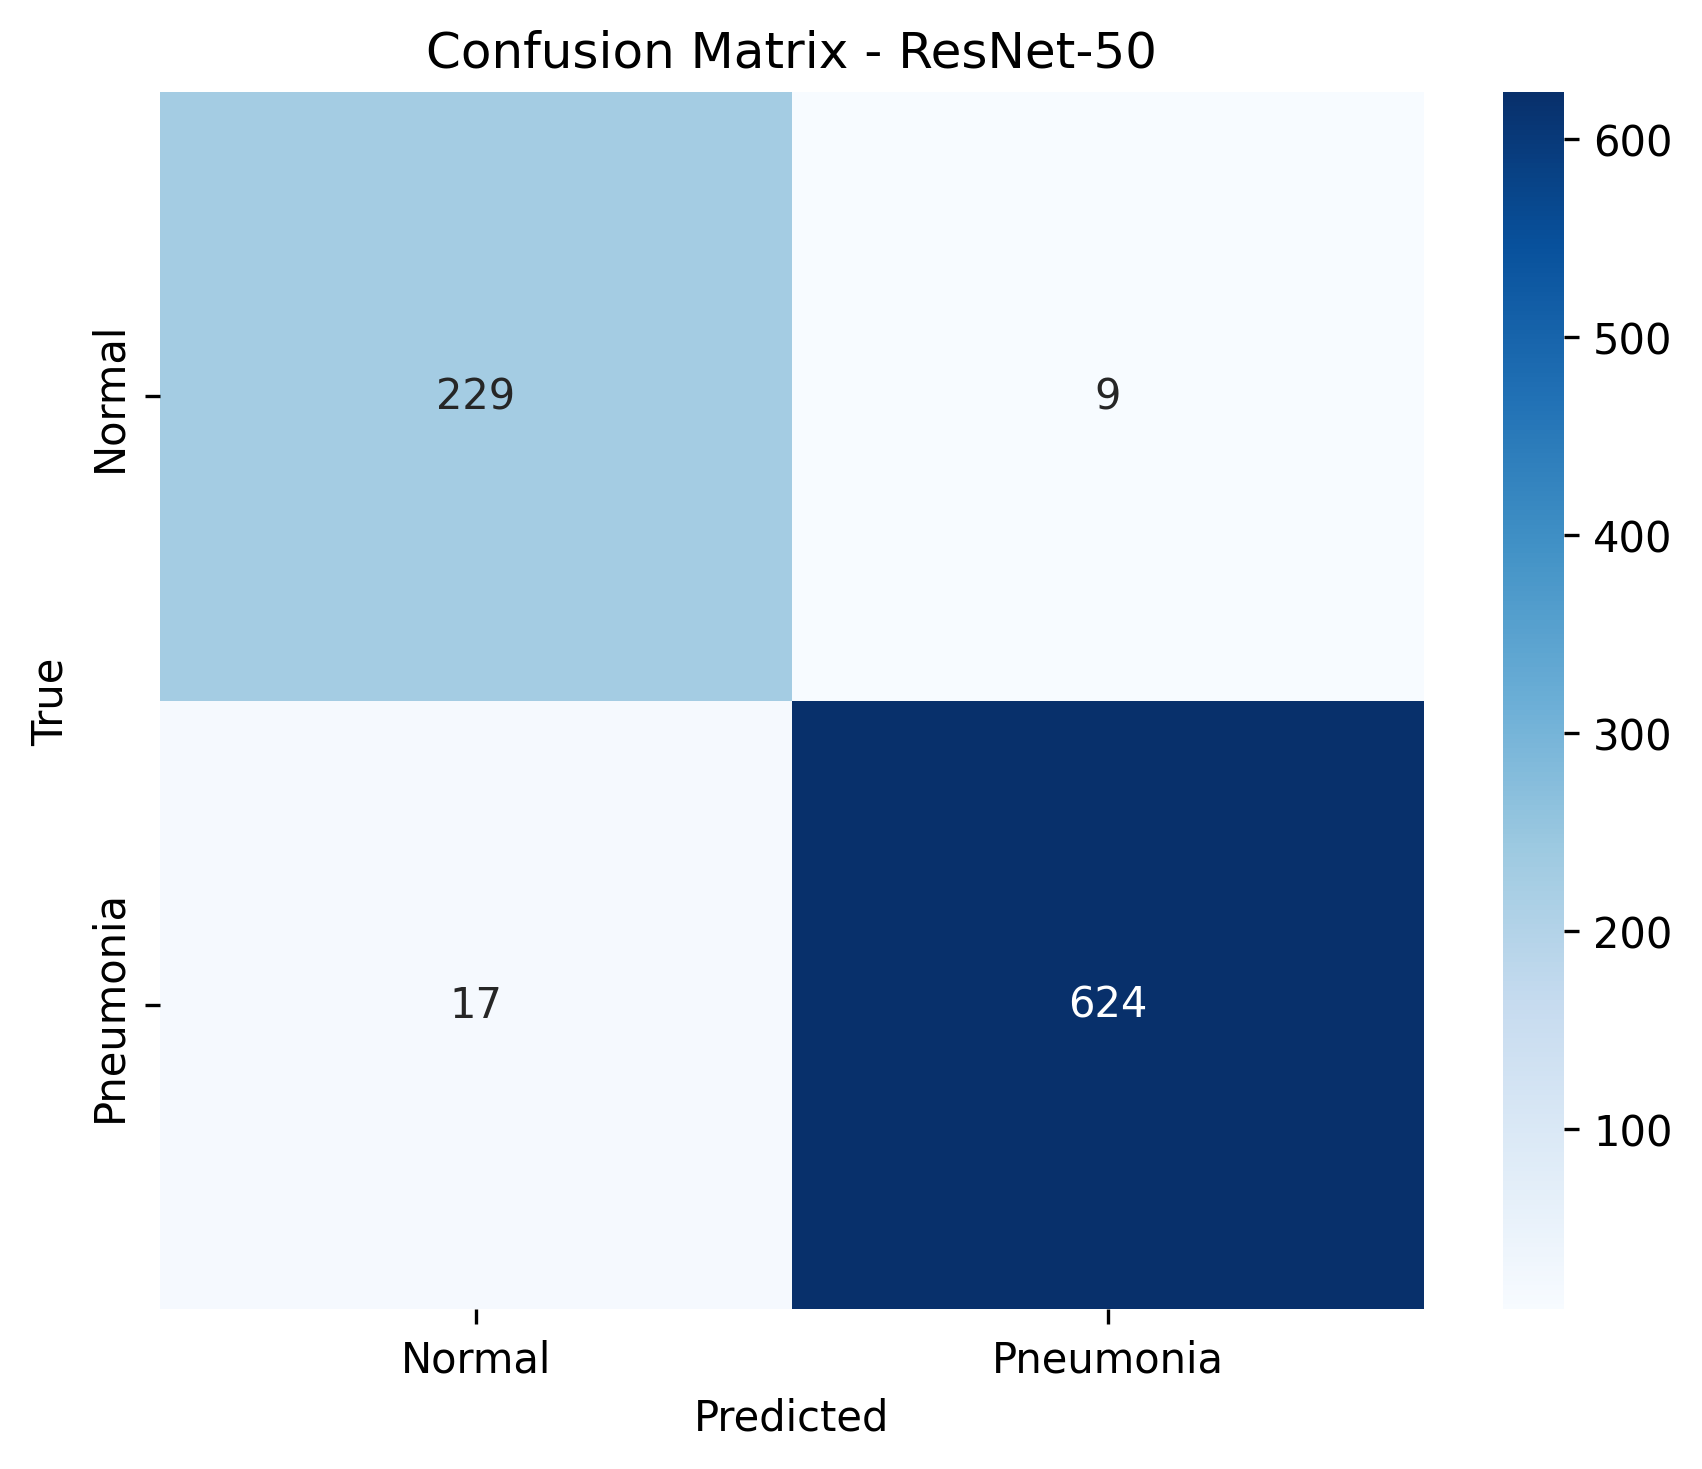

In [4]:
cm_resnet = resnet_evaluation_results['confusion_matrix']
plt.figure(figsize=(6, 5))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ResNet-50')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig7_resnet_50_confusion_matrix.png'))
plt.show()

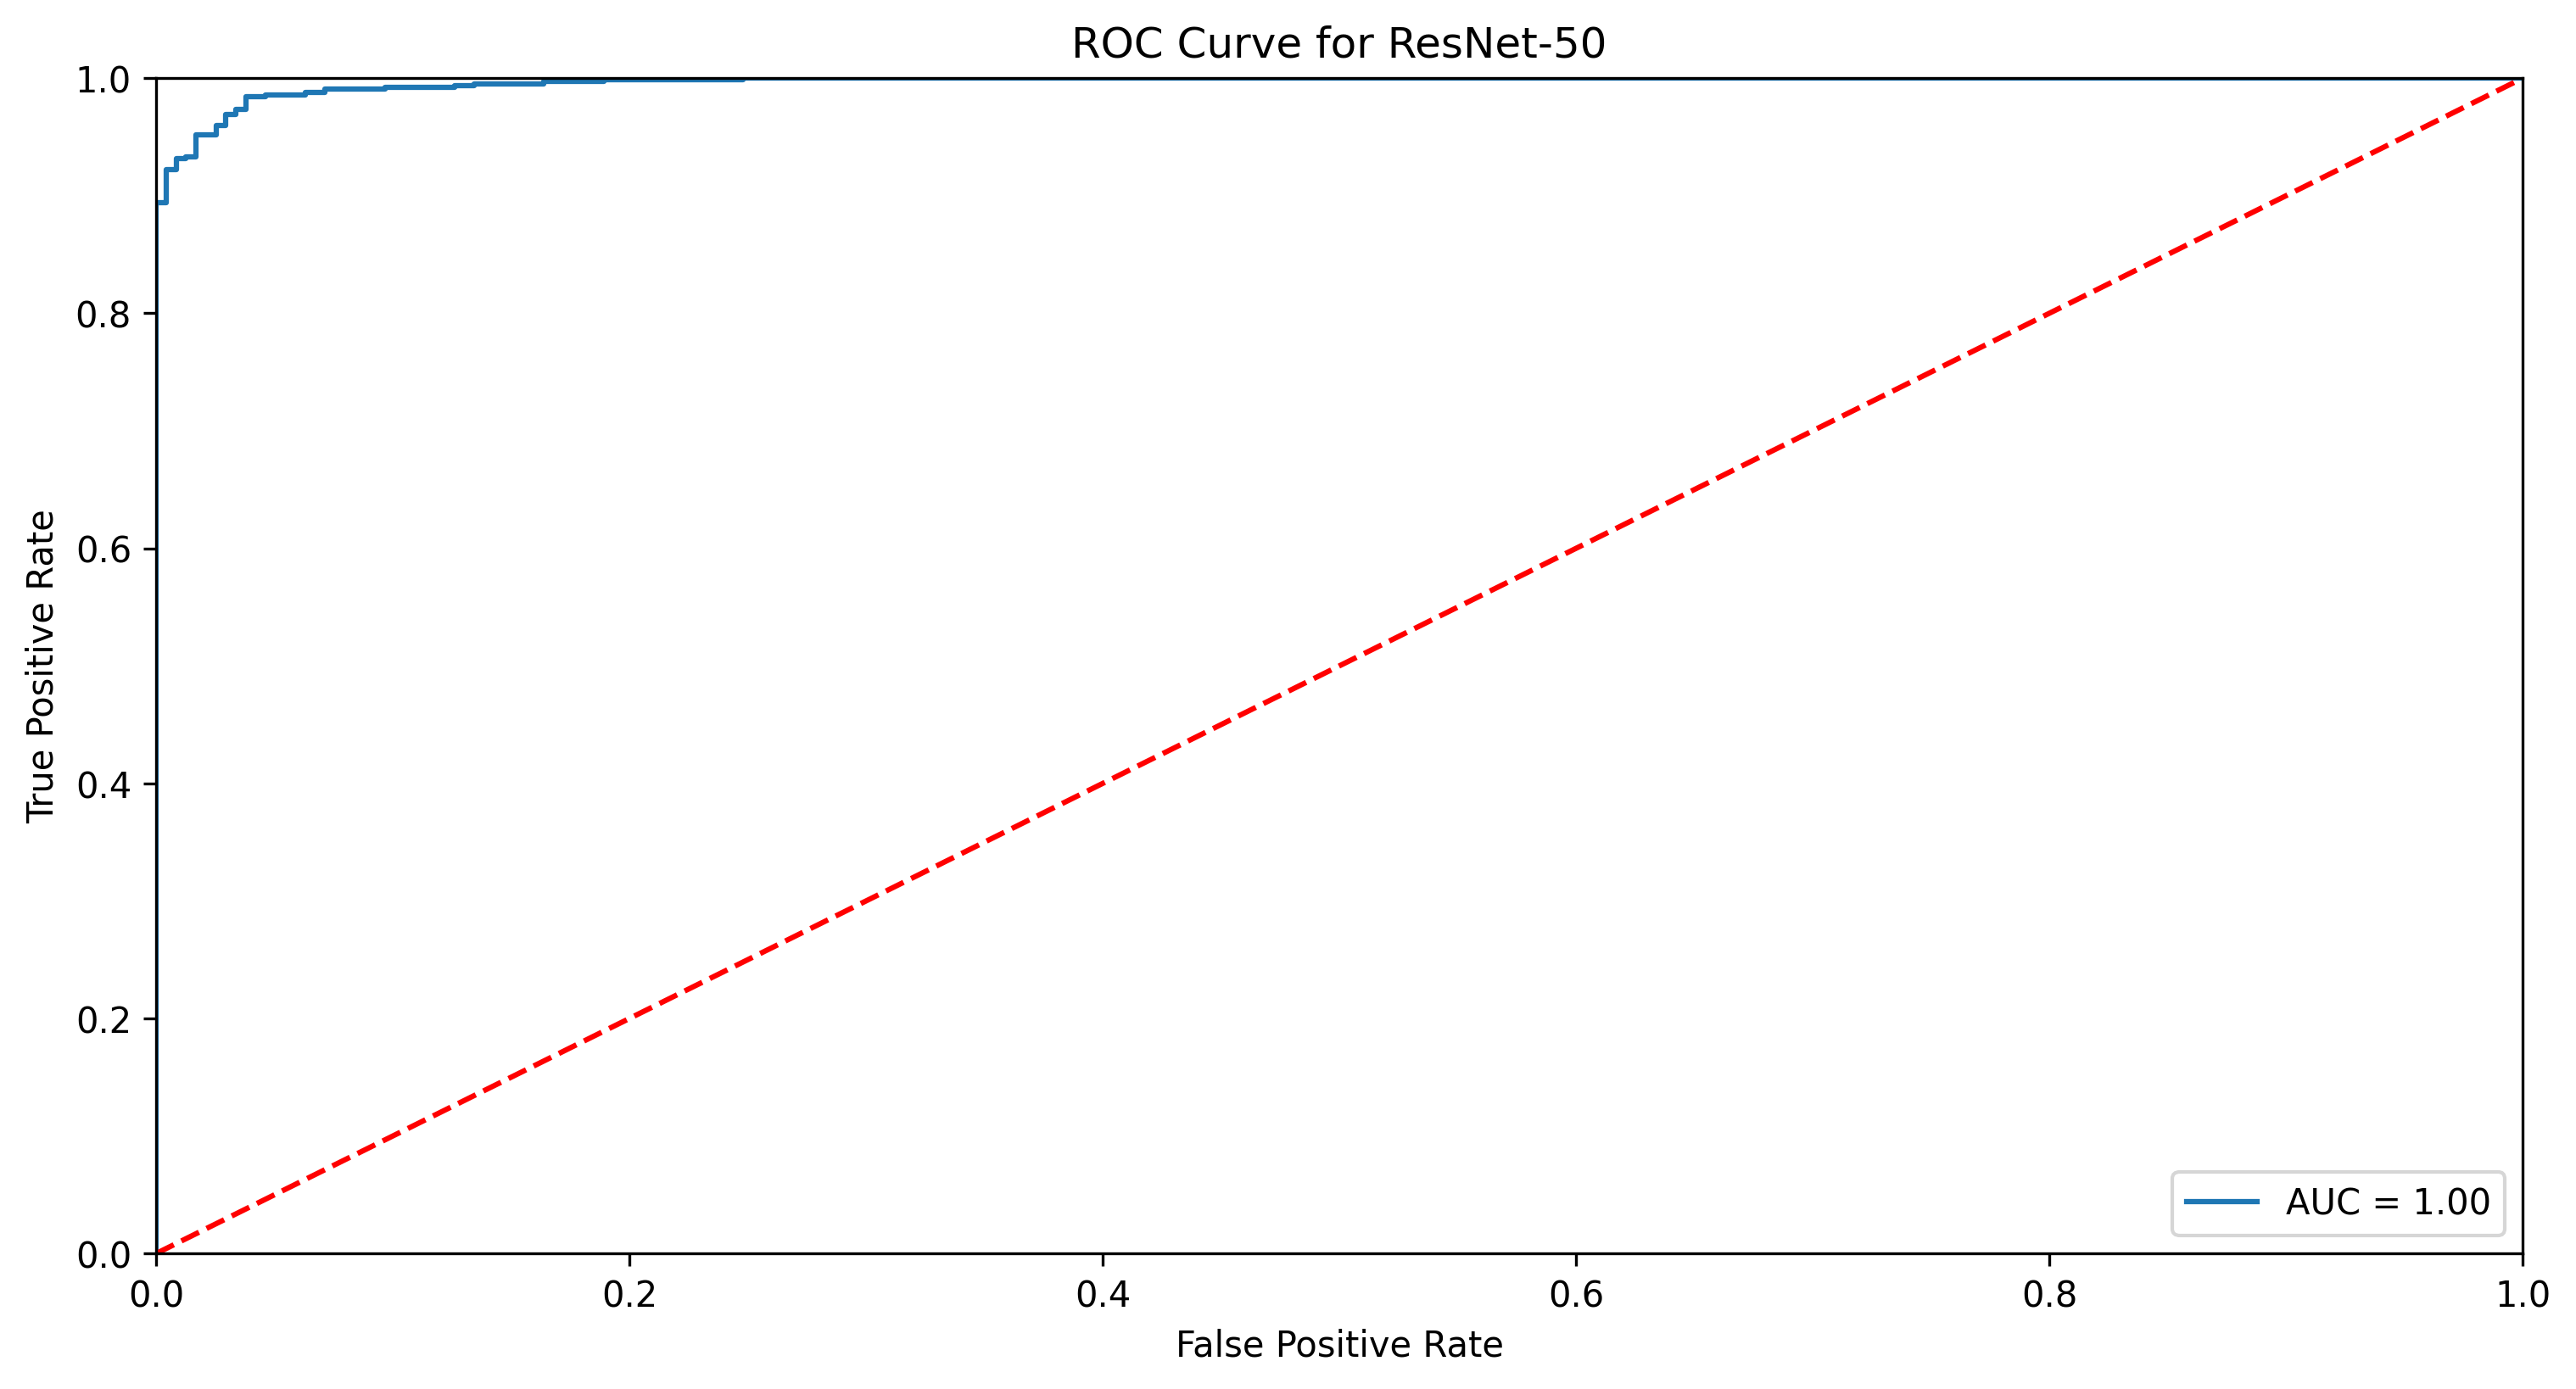

In [5]:
plt.figure(figsize=(12, 6))
plt.title('ROC Curve for ResNet-50')
plt.plot(resnet_evaluation_results['fpr'], resnet_evaluation_results['tpr'], label='AUC = %0.2f' % resnet_evaluation_results['roc_auc'])
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.savefig(os.path.join(FIGURES_DIR, 'fig8_resnet_50_roc_curve.png'))
plt.show()

In [6]:
model_densenet = get_model('densenet121').to(device)

checkpoint = torch.load(os.path.join(MODELS_DIR, 'densenet_121.pth'), map_location=device)
model_densenet.load_state_dict(checkpoint['model_state_dict'])
model_densenet.eval()
print(f"Loaded DenseNet-121 from epoch {checkpoint['epoch']} with val loss {checkpoint['val_loss']:.4f}")

Trainable: 5,525,249 / 6,954,881
Loaded DenseNet-121 from epoch 16 with val loss 0.0293


In [7]:
densenet_evaluation_results = evaluate(model = model_densenet, test_loader=test_loader, device=device)
print_results(densenet_evaluation_results, 'DenseNet-121')


  DenseNet-121 Results
  Accuracy:  0.9761
  Precision: 0.9829
  Recall:    0.9844
  F1 Score:  0.9836
  AUC-ROC:   0.9965
  Confusion Matrix:
[[227  11]
 [ 10 631]]



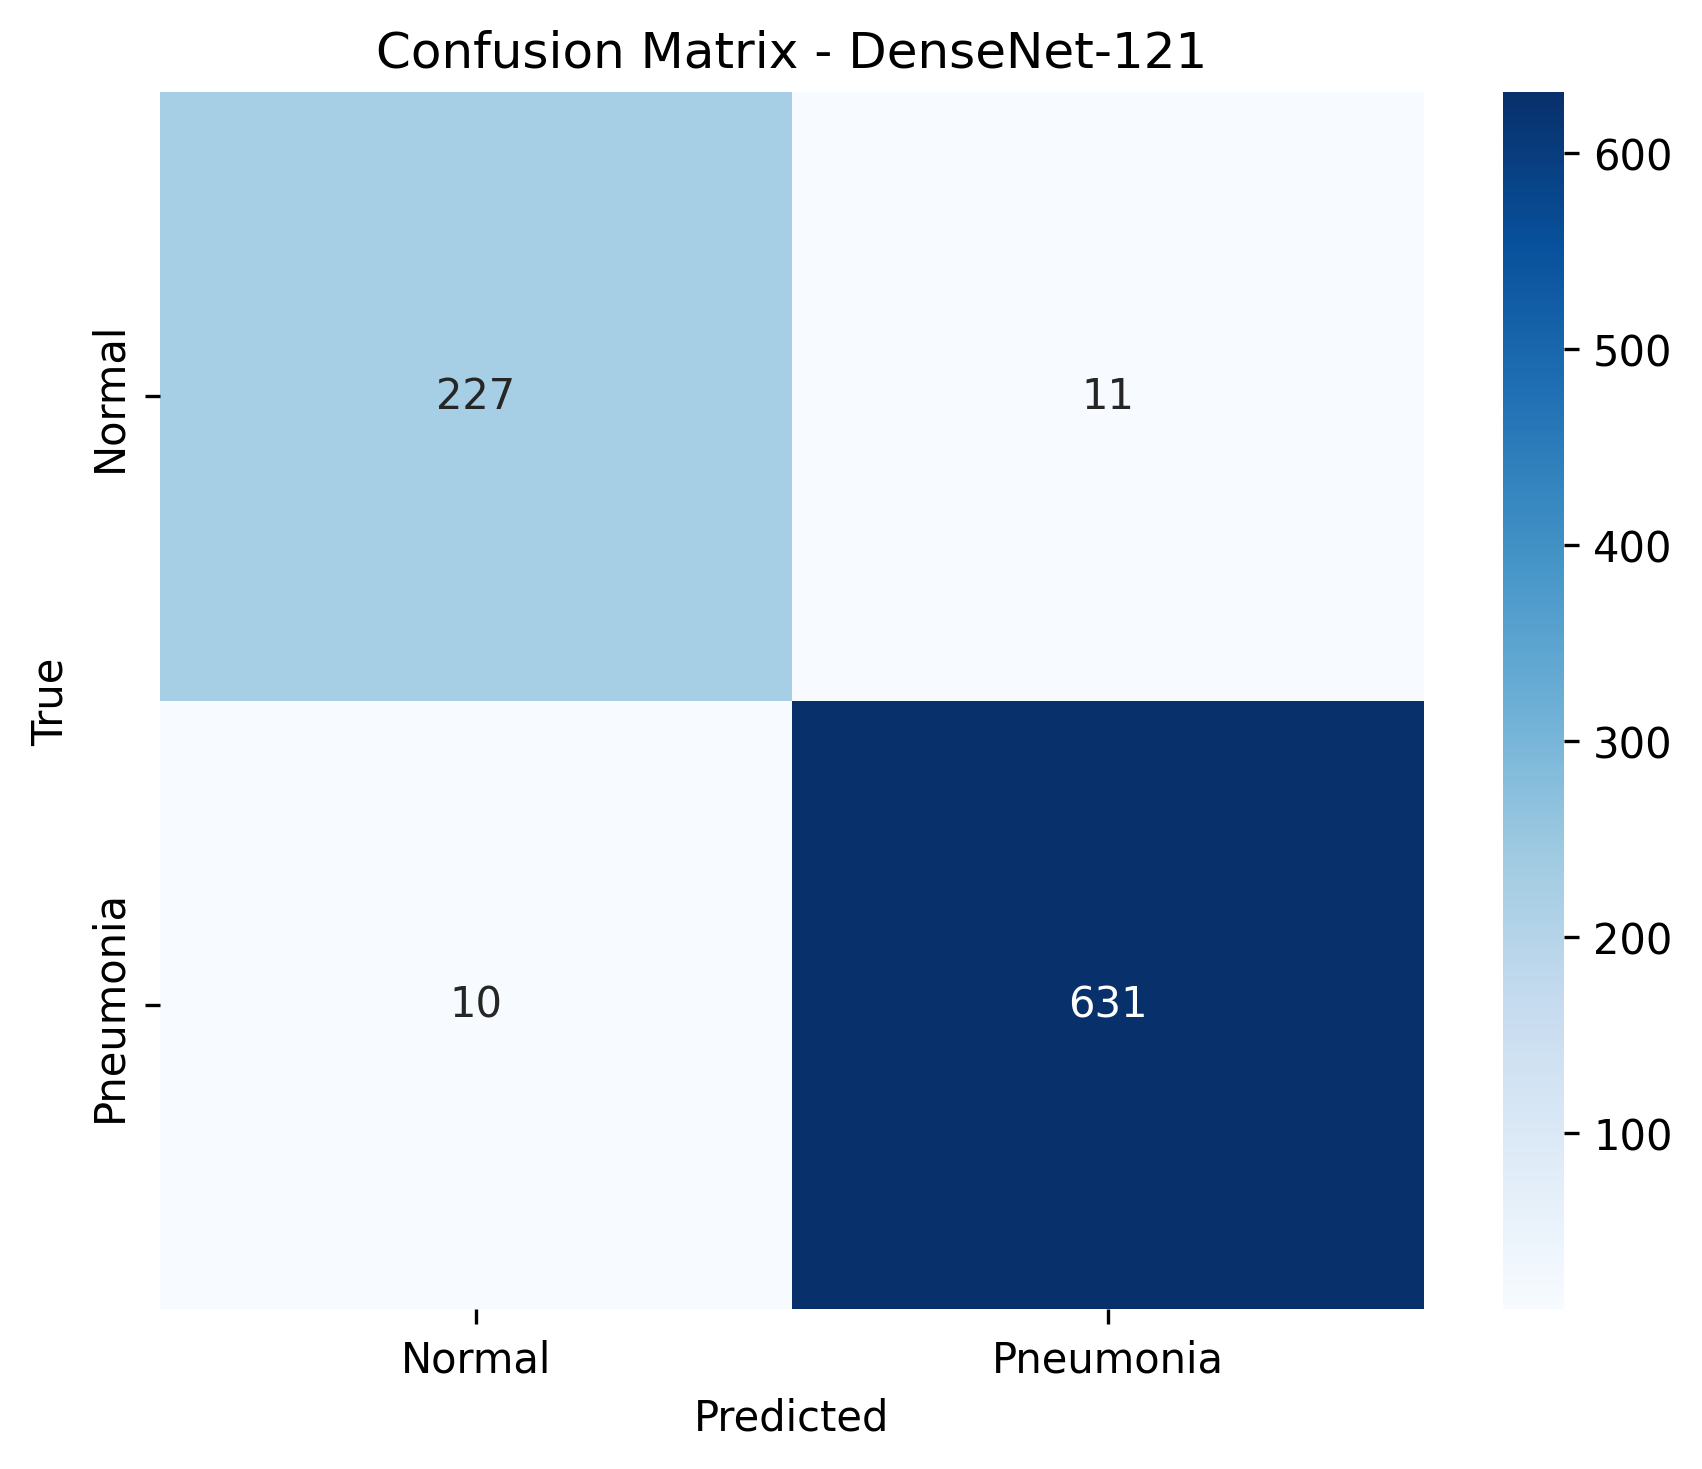

In [8]:
cm_densenet = densenet_evaluation_results['confusion_matrix']
plt.figure(figsize=(6, 5))
sns.heatmap(cm_densenet, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - DenseNet-121')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig9_densenet_121_confusion_matrix.png'))
plt.show()

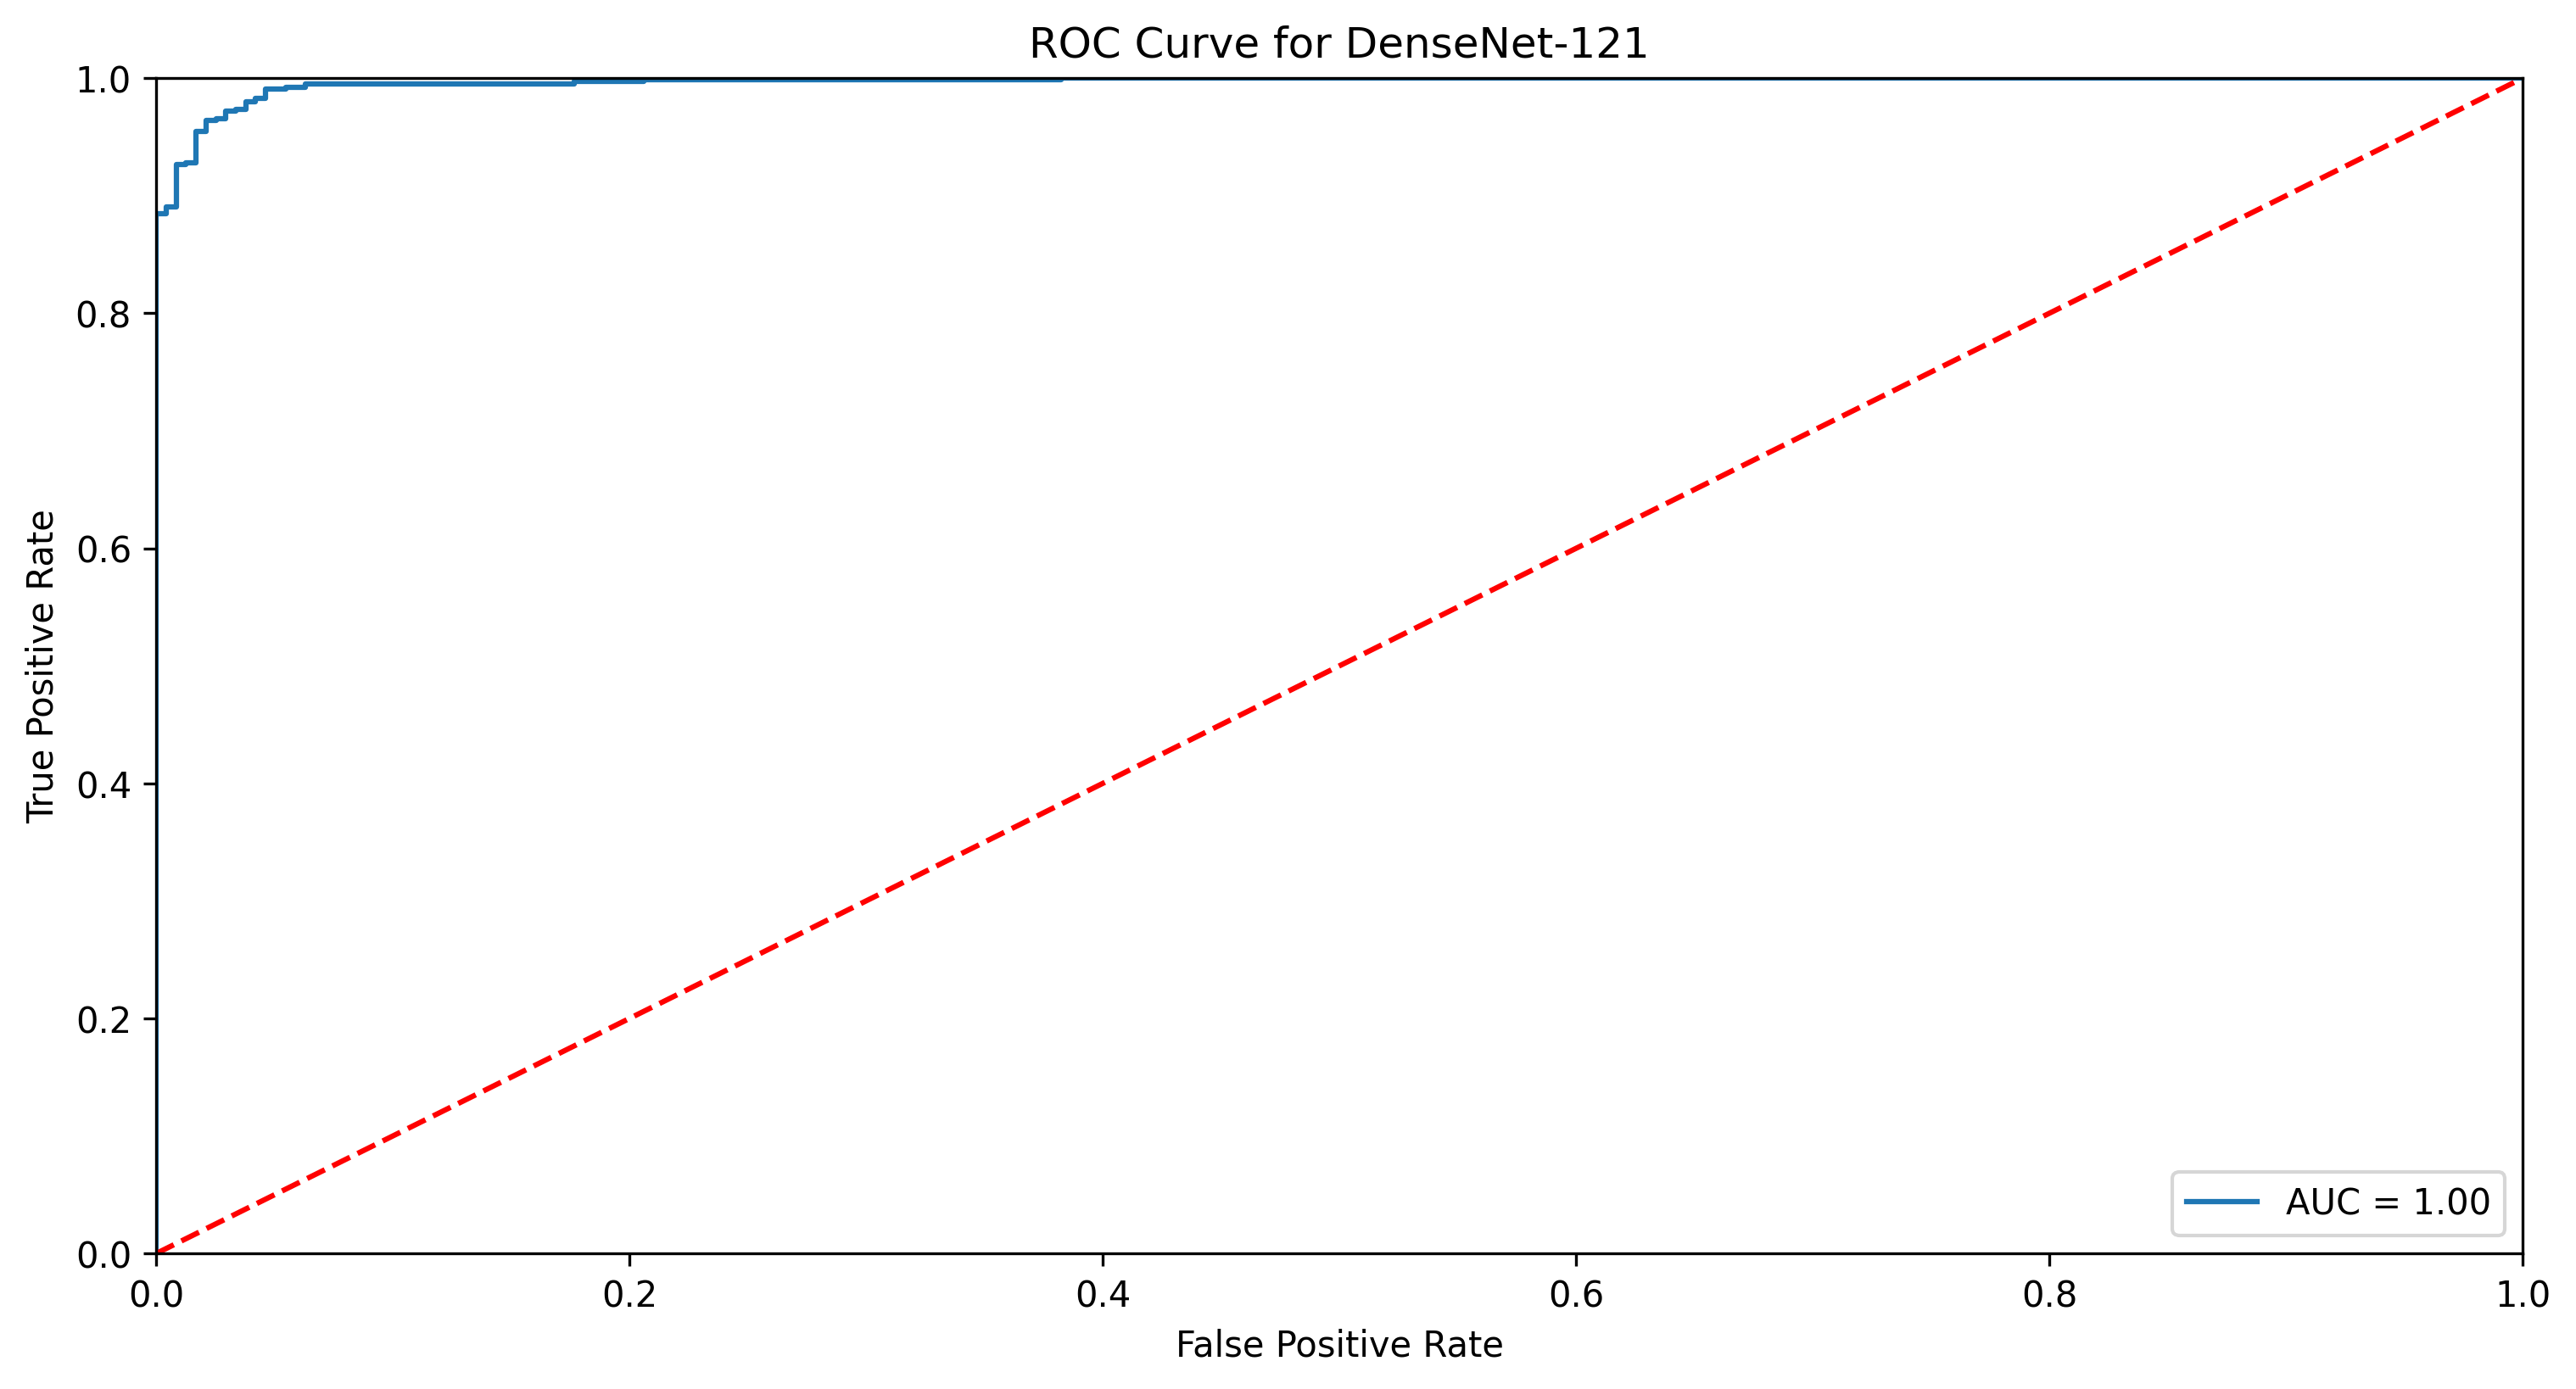

In [9]:
plt.figure(figsize=(12, 6))
plt.title('ROC Curve for DenseNet-121')
plt.plot(densenet_evaluation_results['fpr'], densenet_evaluation_results['tpr'], label='AUC = %0.2f' % densenet_evaluation_results['roc_auc'])
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.savefig(os.path.join(FIGURES_DIR, 'fig10_densenet_121_roc_curve.png'))
plt.show()

In [10]:
model_efficientnet = get_model('efficientnet_b0').to(device)

checkpoint = torch.load(os.path.join(MODELS_DIR, 'efficientnet_b0.pth'), map_location=device)
model_efficientnet.load_state_dict(checkpoint['model_state_dict'])
model_efficientnet.eval()
print(f"Loaded EfficientNet-B0 from epoch {checkpoint['epoch']} with val loss {checkpoint['val_loss']:.4f}")

Trainable: 3,700,169 / 4,008,829
Loaded EfficientNet-B0 from epoch 10 with val loss 0.0322


In [11]:
efficientnet_evaluation_results = evaluate(model = model_efficientnet, test_loader=test_loader, device=device)
print_results(efficientnet_evaluation_results, 'EfficientNet-B0')


  EfficientNet-B0 Results
  Accuracy:  0.9625
  Precision: 0.9935
  Recall:    0.9548
  F1 Score:  0.9737
  AUC-ROC:   0.9964
  Confusion Matrix:
[[234   4]
 [ 29 612]]



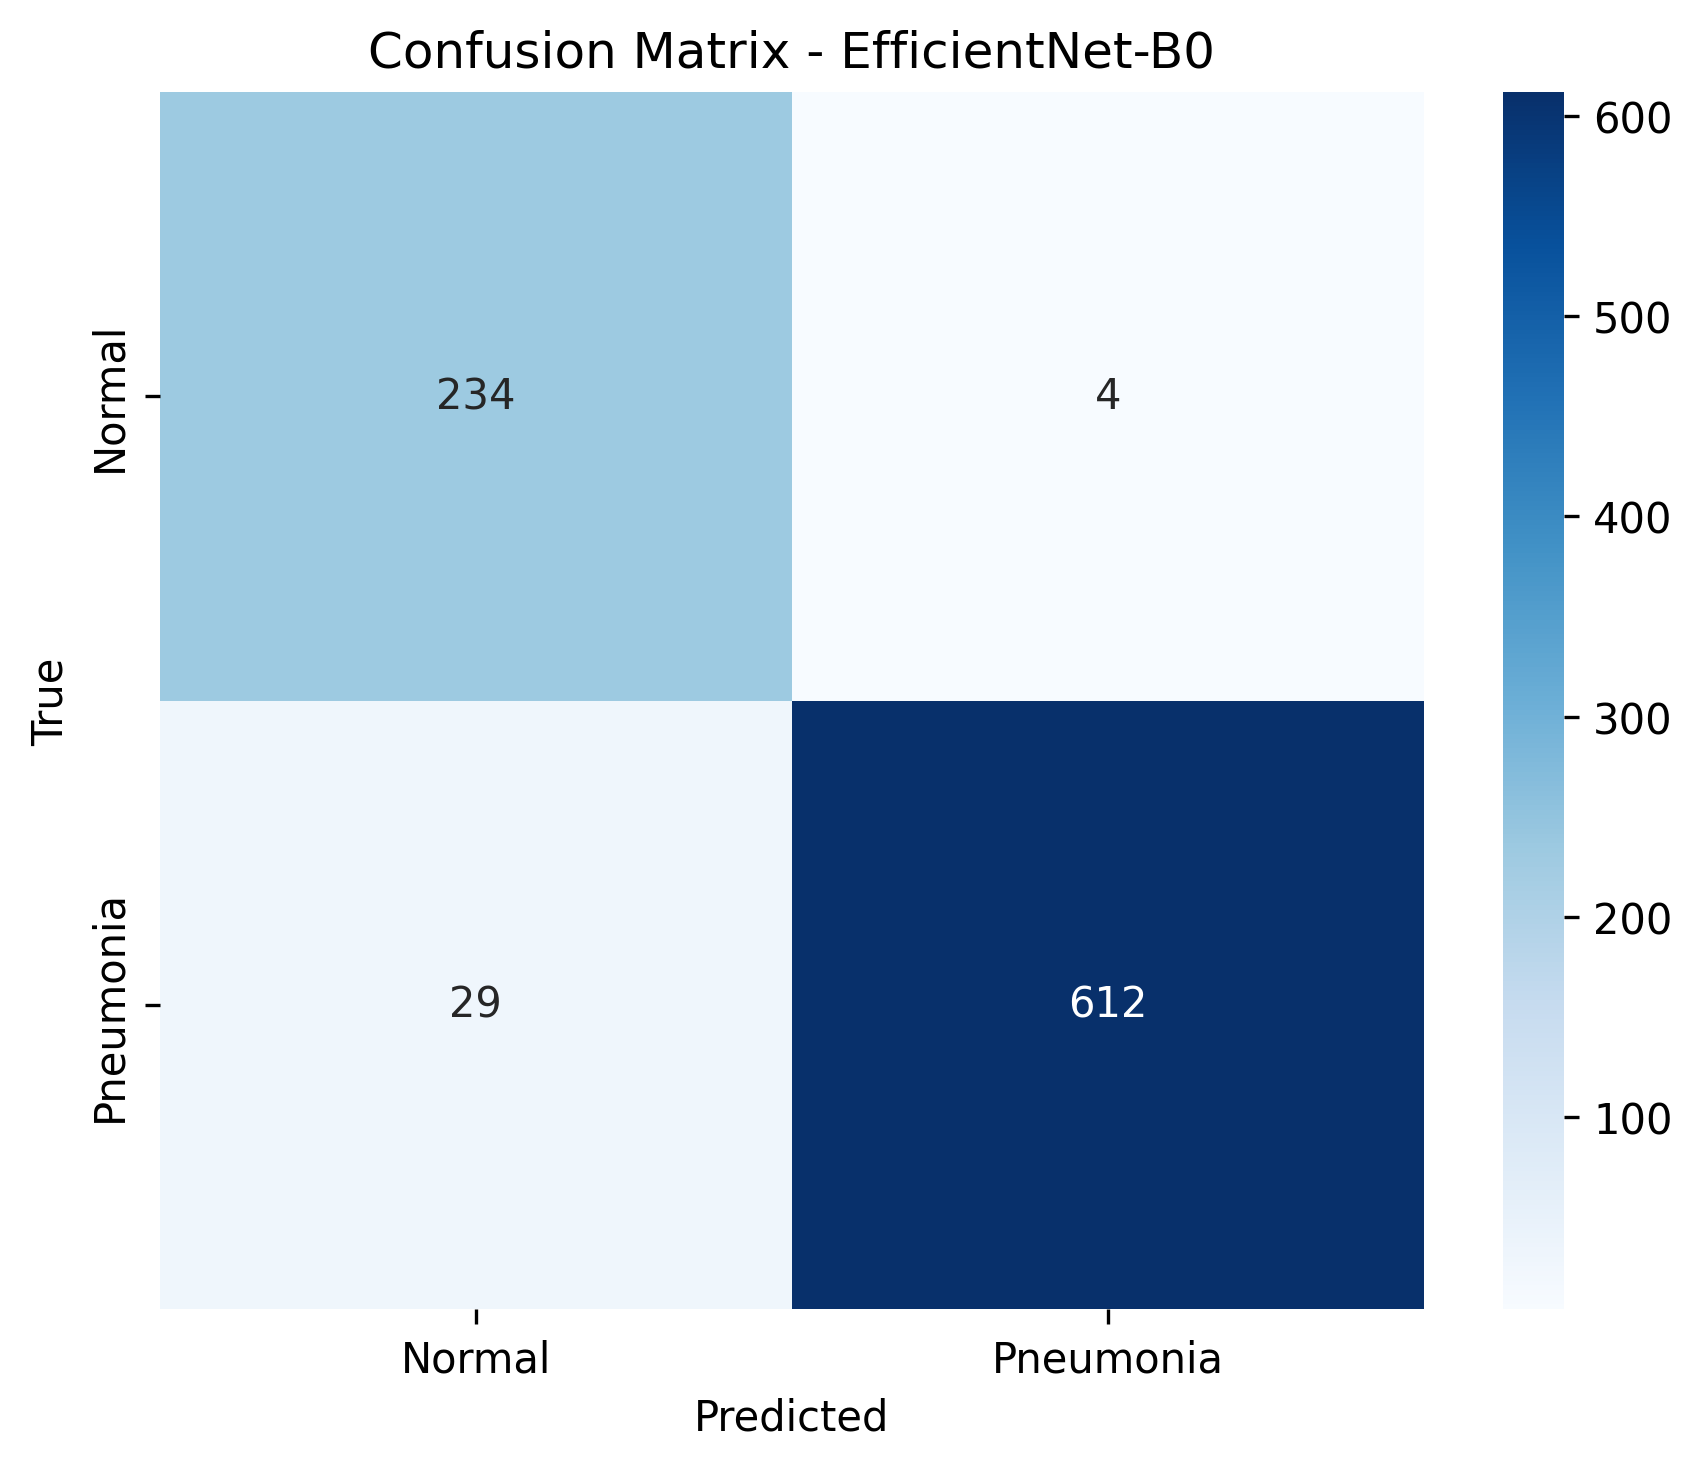

In [12]:
cm_efficientnet = efficientnet_evaluation_results['confusion_matrix']
plt.figure(figsize=(6, 5))
sns.heatmap(cm_efficientnet, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - EfficientNet-B0')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig11_efficientnet_b0_confusion_matrix.png'))
plt.show()

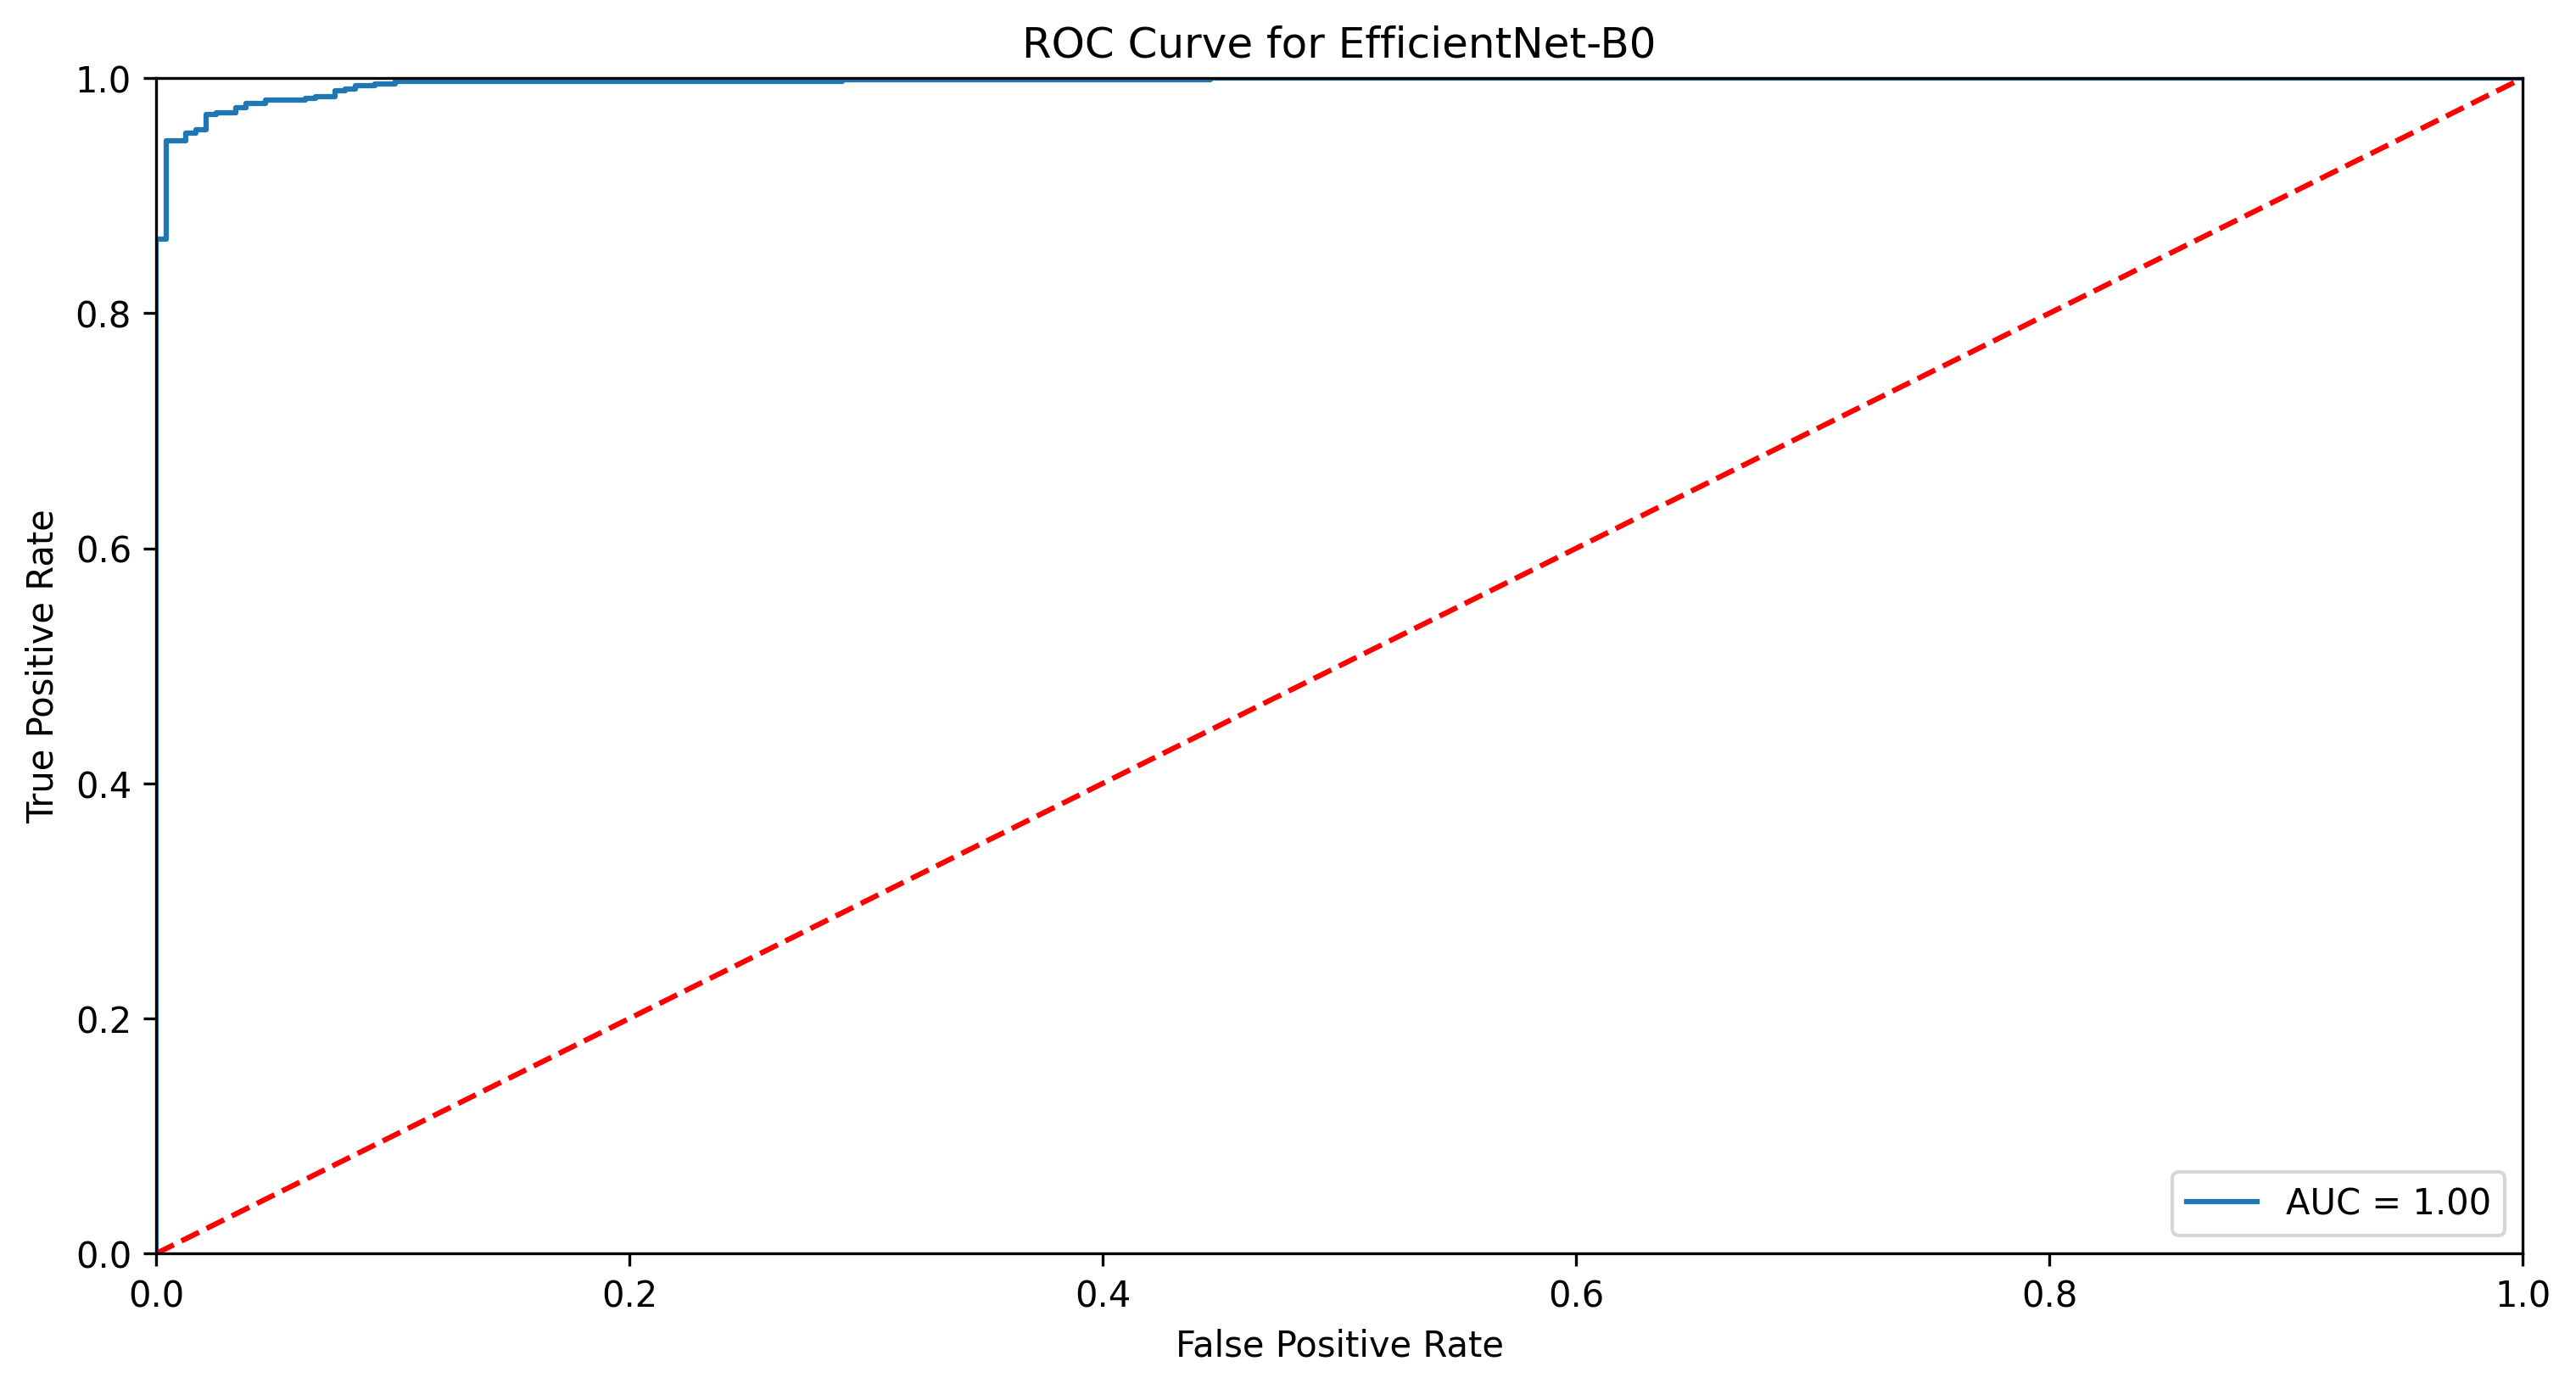

In [13]:
plt.figure(figsize=(12, 6))
plt.title('ROC Curve for EfficientNet-B0')
plt.plot(efficientnet_evaluation_results['fpr'], efficientnet_evaluation_results['tpr'], label='AUC = %0.2f' % efficientnet_evaluation_results['roc_auc'])
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.savefig(os.path.join(FIGURES_DIR, 'fig12_efficientnet_b0_roc_curve.png'))
plt.show()

In [14]:
GradCAM_resnet = GradCAM(model_resnet, target_layer=model_resnet.layer4)
GradCAM_densenet = GradCAM(model_densenet, target_layer=model_densenet.features.denseblock4)
GradCAM_efficientnet = GradCAM(model_efficientnet, target_layer=model_efficientnet.features[8])

In [15]:
sample_pneumonia = None
sample_normal = None
sample_misclassified = None

for idx in range(len(test_loader.dataset)):
    img_tensor, true_label = test_loader.dataset[idx]
    img_tensor = img_tensor.unsqueeze(0).to(device)
    original_img = Image.open(test_loader.dataset.img_paths[idx]).convert('RGB').resize((224, 224))

    with torch.no_grad():
        output = model_densenet(img_tensor).squeeze()

    predicted = (output >= 0).long().item()

    if sample_pneumonia is None and predicted == true_label and true_label == 1:
        sample_pneumonia = (idx, img_tensor, original_img, true_label)

    if sample_normal is None and predicted == true_label and true_label == 0:
        sample_normal = (idx, img_tensor, original_img, true_label)

    if sample_misclassified is None and predicted != true_label:
        sample_misclassified = (idx, img_tensor, original_img, true_label)

    if all([sample_pneumonia, sample_normal, sample_misclassified]):
        break

In [16]:
idx, normal_img_tensor, normal_original_img, true_label = sample_normal
idx, pneumonia_img_tensor, pneumonia_original_img, true_label = sample_pneumonia
idx, misclassified_img_tensor, misclassified_original_img, misclassified_true_label = sample_misclassified

true_label_name = 'Pneumonia' if misclassified_true_label == 1 else 'Normal'

def generate_gradcam(gradcam_model, img_tensor, original_img):
    cam = gradcam_model.generate_heatmap(img_tensor, device=device)

    cam_resized = np.array(Image.fromarray(cam).resize((224, 224), Image.BILINEAR))

    colormap = cm.jet
    heatmap_rgb = colormap(cam_resized)[:, :, :3]

    original_img_np = np.array(original_img) / 255.0

    alpha = 0.4

    overlay = heatmap_rgb * alpha + original_img_np * (1 - alpha)

    return overlay

d:\ATU\Deep Learning\Project\Pneumonia-Detection-Using-Deep-Learning\pneumonia_detection\Lib\site-packages\torch\nn\modules\module.py:1869: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
d:\ATU\Deep Learning\Project\Pneumonia-Detection-Using-Deep-Learning\pneumonia_detection\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:410.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


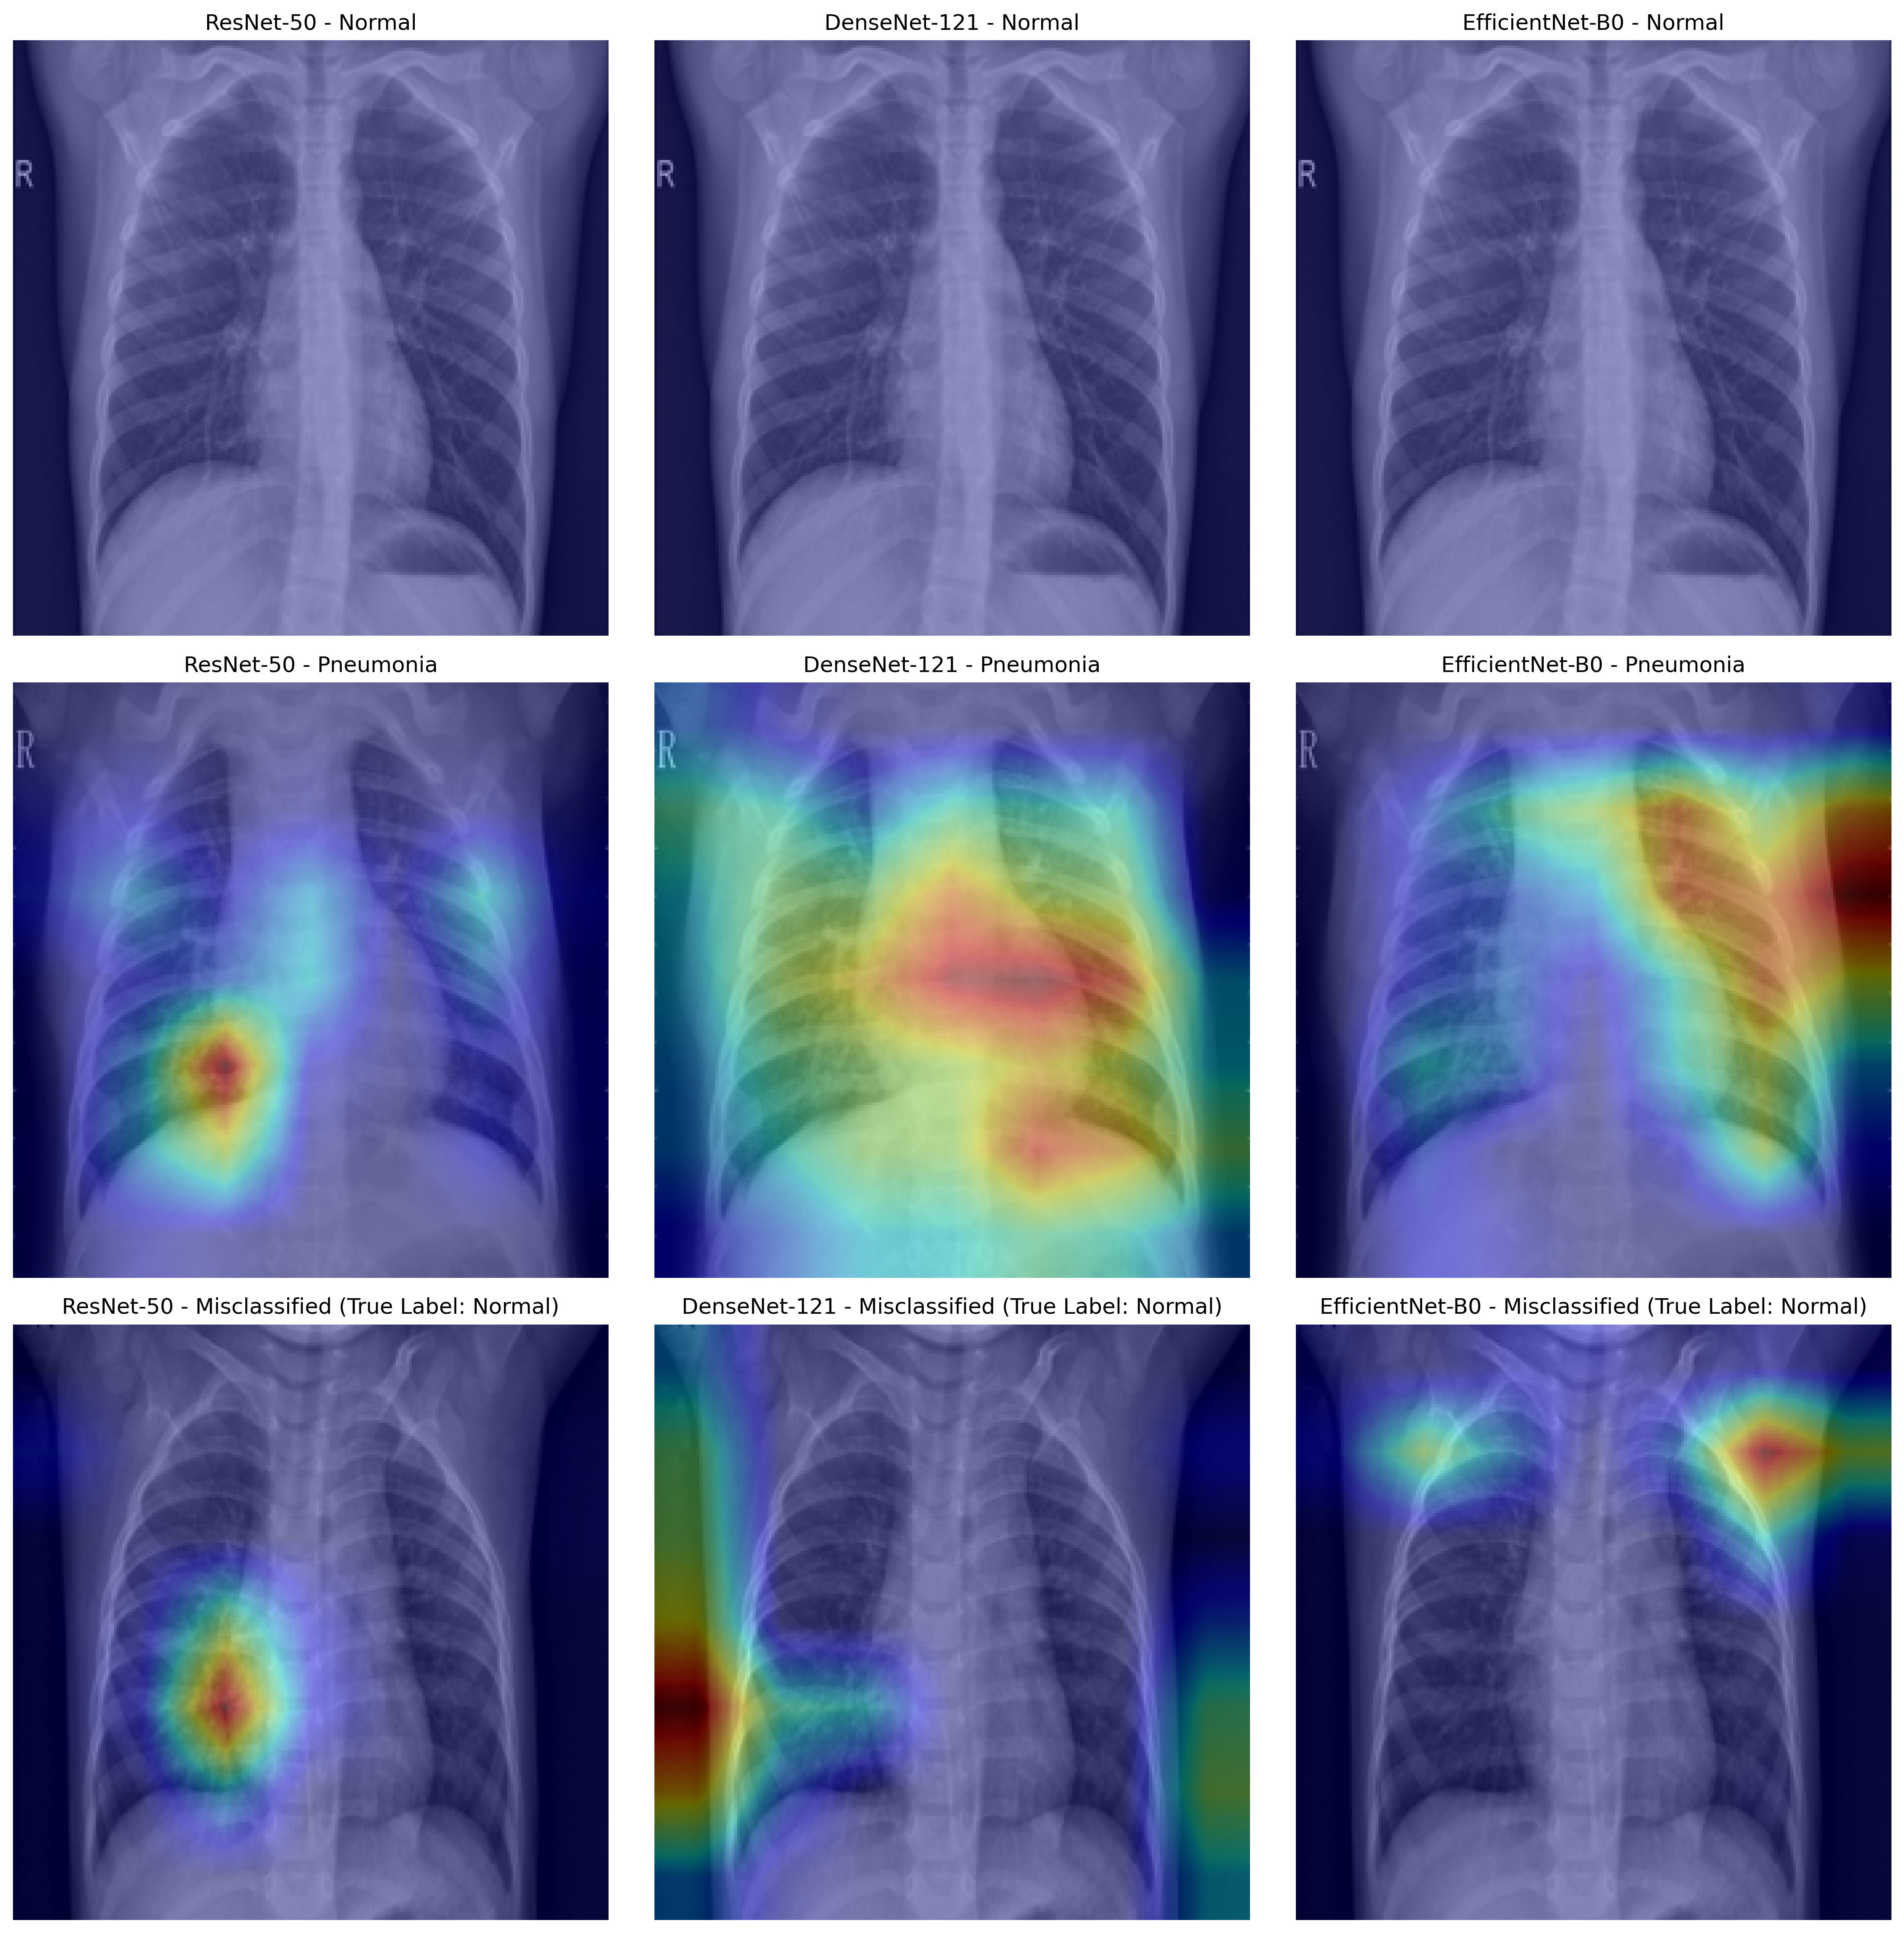

In [ ]:
plt.figure(figsize=(15, 15))
plt.subplot(3, 3, 1)
plt.imshow(generate_gradcam(GradCAM_resnet, normal_img_tensor, normal_original_img))
plt.axis('off')
plt.title('ResNet-50 - Normal')
plt.subplot(3, 3, 2)
plt.imshow(generate_gradcam(GradCAM_densenet, normal_img_tensor, normal_original_img))
plt.axis('off')
plt.title('DenseNet-121 - Normal')
plt.subplot(3, 3, 3)
plt.imshow(generate_gradcam(GradCAM_efficientnet, normal_img_tensor, normal_original_img))
plt.axis('off')
plt.title('EfficientNet-B0 - Normal')
plt.subplot(3, 3, 4)
plt.imshow(generate_gradcam(GradCAM_resnet, pneumonia_img_tensor, pneumonia_original_img))
plt.axis('off')
plt.title('ResNet-50 - Pneumonia')
plt.subplot(3, 3, 5)
plt.imshow(generate_gradcam(GradCAM_densenet, pneumonia_img_tensor, pneumonia_original_img))
plt.axis('off')
plt.title('DenseNet-121 - Pneumonia')
plt.subplot(3, 3, 6)
plt.imshow(generate_gradcam(GradCAM_efficientnet, pneumonia_img_tensor, pneumonia_original_img))
plt.axis('off')
plt.title('EfficientNet-B0 - Pneumonia')
plt.subplot(3, 3, 7)
plt.imshow(generate_gradcam(GradCAM_resnet, misclassified_img_tensor, misclassified_original_img))
plt.axis('off')
plt.title('ResNet-50 - Misclassified (True Label: ' + true_label_name + ')')
plt.subplot(3, 3, 8)
plt.imshow(generate_gradcam(GradCAM_densenet, misclassified_img_tensor, misclassified_original_img))
plt.axis('off')
plt.title('DenseNet-121 - Misclassified (True Label: ' + true_label_name + ')')
plt.subplot(3, 3, 9)
plt.imshow(generate_gradcam(GradCAM_efficientnet, misclassified_img_tensor, misclassified_original_img))
plt.axis('off')
plt.title('EfficientNet-B0 - Misclassified (True Label: ' + true_label_name + ')')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig13_gradcam_comparison.png'))
plt.show()

In [18]:
GradCAM_resnet.remove_hooks()
GradCAM_densenet.remove_hooks()
GradCAM_efficientnet.remove_hooks()